## Aravind's Contribution - Gaussian Blur, Histogram Equalization & Intensity thresholds + Test & Train Split + VGG16 Model Training and Evaluation

### Hence we have already did the EDA and Preprocessing earlier in the last assignment, I am now doing the things which were left in the last submission test-train test split and 	Gaussian Blur, Histogram Equalization and Intensity thresholds also Train & Test Split.

## Applying - Gaussian Blur, Histogram Equalization & Intensity thresholds

In [15]:
import os
from PIL import Image
import cv2
import numpy as np

# Function to apply Gaussian Blur
def apply_gaussian_blur(image):
    img = np.array(image)
    blurred_image = cv2.GaussianBlur(img, (5, 5), 0)
    return Image.fromarray(blurred_image)

# Function to apply Histogram Equalization
def apply_histogram_equalization(image):
    img = np.array(image)
    if len(img.shape) == 2:  # Grayscale image
        eq_img = cv2.equalizeHist(img)
    else:  # Color image
        img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])  # Equalizing the Y channel
        eq_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    return Image.fromarray(eq_img)

# Function to apply Intensity Thresholding
def apply_intensity_threshold(image, threshold=128):
    img = np.array(image.convert("L"))
    _, thresholded_img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    return Image.fromarray(thresholded_img)

# Function to augment a single image
def augment_image(image_path, augmented_folder, img_count):
    img = Image.open(image_path)
    
    # Apply augmentations
    img_blurred = apply_gaussian_blur(img)
    img_eq = apply_histogram_equalization(img)
    img_thresholded = apply_intensity_threshold(img)

    # Save the augmented images
    img_blurred.save(os.path.join(augmented_folder, f"augmented_{img_count}_blurred.jpg"))
    img_eq.save(os.path.join(augmented_folder, f"augmented_{img_count}_equalized.jpg"))
    img_thresholded.save(os.path.join(augmented_folder, f"augmented_{img_count}_thresholded.jpg"))

# Function to augment all images in a class folder
def augment_class_images(label_name, source_folder, augmented_folder):
    os.makedirs(augmented_folder, exist_ok=True)
    
    # Load existing images in the class folder
    all_files = os.listdir(source_folder)
    print(f"Augmenting {label_name} class...")

    img_count = 0  # Start counting from original images
    for file in all_files:
        image_path = os.path.join(source_folder, file)
        augment_image(image_path, augmented_folder, img_count)
        img_count += 1

    print(f"Augmented {label_name} to {img_count} samples.")

# Paths for augmenting
data_dir = './yelp_photos/balanced_labeled_photos'  # The original balanced dataset
augmented_data_dir = './yelp_photos/augmented_labeled_photos'  # The directory to save augmented data

# Augment all classes in the balanced dataset
for label in os.listdir(data_dir):
    label_folder = os.path.join(data_dir, label)
    
    # Skip if the label folder is not a directory
    if not os.path.isdir(label_folder):
        continue
    
    # Define augmented folder for the current class
    augmented_folder = os.path.join(augmented_data_dir, label)
    
    # Augment the class images
    augment_class_images(label, label_folder, augmented_folder)

print("Data augmentation completed.")

Augmenting drink class...
Augmented drink to 15670 samples.
Augmenting food class...
Augmented food to 20000 samples.
Augmenting inside class...
Augmented inside to 20000 samples.
Augmenting menu class...
Augmented menu to 20000 samples.
Augmenting outside class...
Augmented outside to 18569 samples.
Data augmentation completed.


## After Augmentation Viewing sample images

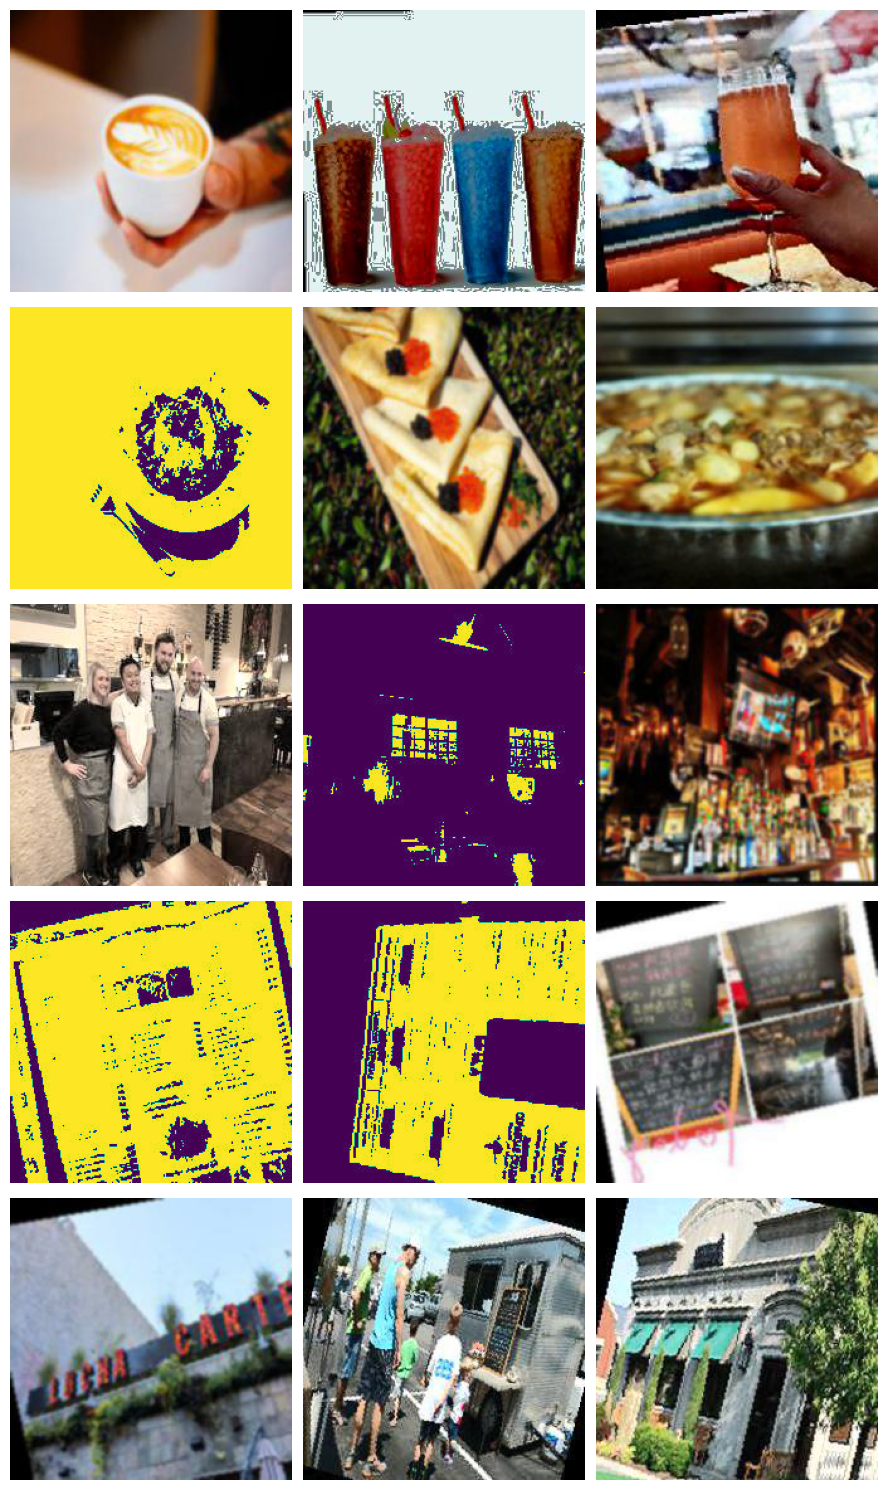

In [19]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to the augmented dataset
augmented_data_dir = './yelp_photos/augmented_labeled_photos'

# Number of images to display per class (for each of the augmented versions)
images_per_class = 3

# Create a plot with subplots
fig, axs = plt.subplots(len(os.listdir(augmented_data_dir)), images_per_class, figsize=(images_per_class * 3, len(os.listdir(augmented_data_dir)) * 3))

# Loop through each class in the augmented dataset directory
for i, label in enumerate(os.listdir(augmented_data_dir)):
    label_folder = os.path.join(augmented_data_dir, label)
    
    # Skip if the label folder is not a directory
    if not os.path.isdir(label_folder):
        continue
    
    # Get a list of all image files in the class folder (blurred, equalized, thresholded)
    all_files = os.listdir(label_folder)
    
    # Select 3 random images for display (we assume there are at least 3 images)
    selected_files = random.sample(all_files, images_per_class)
    
    # Display the images
    for j, img_file in enumerate(selected_files):
        img_path = os.path.join(label_folder, img_file)
        img = Image.open(img_path)
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
        if j == 0:
            axs[i, j].set_ylabel(label, fontsize=12)

# Adjust the layout to make it fit properly
plt.tight_layout()
plt.show()

## Train - Test Split (80-20 Ratio)
### Import All Augmented Versions (Blurred, Equalized, Thresholded)

In [51]:
import os
import shutil

# Paths
augmented_data_dir = './yelp_photos/augmented_labeled_photos'
train_dir = './yelp_photos/train_data'
test_dir = './yelp_photos/test_data'

# Create the output directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Number of images per class (10,000)
images_per_class = 10000

# Split ratio
split_ratio = 0.8  # 80-20 split

# Loop through each class folder in the augmented dataset directory
for label in os.listdir(augmented_data_dir):
    label_folder = os.path.join(augmented_data_dir, label)
    
    # Skip if the label folder is not a directory
    if not os.path.isdir(label_folder):
        continue
    
    # Create train and test label folders
    train_label_folder = os.path.join(train_dir, label)
    test_label_folder = os.path.join(test_dir, label)
    
    os.makedirs(train_label_folder, exist_ok=True)
    os.makedirs(test_label_folder, exist_ok=True)
    
    # Get all image files in the current class folder
    all_files = os.listdir(label_folder)
    
    # Filter the files to include only images
    image_files = [file for file in all_files if file.endswith(('jpg', 'jpeg', 'png'))]
    
    # Group files by their base name (before augmentation suffix)
    base_files = {}
    for file in image_files:
        # Extract base name by removing augmentation suffixes
        if '_blurred.' in file:
            base_name = file.replace('_blurred.jpg', '').replace('_blurred.jpeg', '').replace('_blurred.png', '')
        elif '_equalized.' in file:
            base_name = file.replace('_equalized.jpg', '').replace('_equalized.jpeg', '').replace('_equalized.png', '')
        elif '_thresholded.' in file:
            base_name = file.replace('_thresholded.jpg', '').replace('_thresholded.jpeg', '').replace('_thresholded.png', '')
        else:
            # If no augmentation suffix, use the filename without extension
            base_name = os.path.splitext(file)[0]
        
        if base_name not in base_files:
            base_files[base_name] = []
        base_files[base_name].append(file)
    
    # Get unique base names and ensure we have enough
    unique_base_names = list(base_files.keys())
    
    if len(unique_base_names) * 3 < images_per_class:  # Assuming 3 augmentations per base image
        print(f"Skipping class {label}: Less than {images_per_class // 3} base images found.")
        continue
    
    # Take only the required number of base names
    selected_base_names = unique_base_names[:images_per_class // 3]
    
    # Split the base names into train and test
    train_base_names = selected_base_names[:int(len(selected_base_names) * split_ratio)]
    test_base_names = selected_base_names[int(len(selected_base_names) * split_ratio):]
    
    # Copy training files
    train_count = 0
    for base_name in train_base_names:
        for file in base_files[base_name]:
            src_path = os.path.join(label_folder, file)
            if os.path.exists(src_path):
                dst_path = os.path.join(train_label_folder, file)
                shutil.copy2(src_path, dst_path)
                train_count += 1
            else:
                print(f"File not found: {src_path}")
    
    # Copy test files
    test_count = 0
    for base_name in test_base_names:
        for file in base_files[base_name]:
            src_path = os.path.join(label_folder, file)
            if os.path.exists(src_path):
                dst_path = os.path.join(test_label_folder, file)
                shutil.copy2(src_path, dst_path)
                test_count += 1
            else:
                print(f"File not found: {src_path}")
    
    print(f"Processed {label}: {train_count} train samples, {test_count} test samples")

print("Train-test split completed with 80-20 split, importing all augmented images.")

Processed drink: 7998 train samples, 2001 test samples
Processed food: 7998 train samples, 2001 test samples
Processed inside: 7998 train samples, 2001 test samples
Processed menu: 7998 train samples, 2001 test samples
Processed outside: 7998 train samples, 2001 test samples
Train-test split completed with 80-20 split, importing all augmented images.


## Implementing PreTrained VGG16 Model

In [60]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Concatenate, Input
from tensorflow.keras.callbacks import EarlyStopping

## Loading Meta Data

In [69]:
# Load JSON metadata
metadata_file = './yelp_photos/photos.json'

# Read JSON file and parse the data
with open(metadata_file, 'r') as f:
    metadata = [json.loads(line) for line in f]

# Convert to DataFrame for easier manipulation
df_metadata = pd.DataFrame(metadata)

# Preview metadata
print(df_metadata.head())

                 photo_id             business_id  \
0  zsvj7vloL4L5jhYyPIuVwg  Nk-SJhPlDBkAZvfsADtccA   
1  HCUdRJHHm_e0OCTlZetGLg  yVZtL5MmrpiivyCIrVkGgA   
2  vkr8T0scuJmGVvN2HJelEA  _ab50qdWOk0DdB6XOrBitw   
3  pve7D6NUrafHW3EAORubyw  SZU9c8V2GuREDN5KgyHFJw   
4  H52Er-uBg6rNrHcReWTD2w  Gzur0f0XMkrVxIwYJvOt2g   

                                             caption    label  
0  Nice rock artwork everywhere and craploads of ...   inside  
1                                                     outside  
2                                     oyster shooter    drink  
3                                      Shrimp scampi     food  
4                                                        food  


## Preprocess Metadata
- One-Hot Encode Categorical Features 
- Vectorize Text Features

In [82]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

In [84]:
from sklearn.preprocessing import LabelEncoder

# Step 1: Integer encode 'business_id' column
label_encoder = LabelEncoder()
df_metadata['business_id_encoded'] = label_encoder.fit_transform(df_metadata['business_id'])

# Step 2: One-hot encode 'label' 
encoder = OneHotEncoder(sparse_output=False)
labels = encoder.fit_transform(df_metadata[['label']])

# Step 3: Preprocess the 'caption' column using TF-IDF (text vectorization)
tfidf_vectorizer = TfidfVectorizer(max_features=500)  # Limit to 500 words/features
captions_tfidf = tfidf_vectorizer.fit_transform(df_metadata['caption']).toarray()

# Step 4: Combine the one-hot encoded and integer encoded data
metadata_features = np.concatenate([labels, df_metadata['business_id_encoded'].values.reshape(-1, 1), captions_tfidf], axis=1)

print("Processed metadata shape:", metadata_features.shape)

Processed metadata shape: (200100, 506)


## Image Data Generator

In [88]:
# Image data generator with rescaling
train_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values to [0, 1]
test_datagen = ImageDataGenerator(rescale=1./255)

# Image directories (adjust to your paths)
train_image_dir = './yelp_photos/train_data'
test_image_dir = './yelp_photos/test_data'

train_generator = train_datagen.flow_from_directory(
    train_image_dir,
    target_size=(224, 224),  # Resize images to VGG input size
    batch_size=32,
    class_mode='categorical'  # Multi-class classification
)

test_generator = test_datagen.flow_from_directory(
    test_image_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 39990 images belonging to 5 classes.
Found 10005 images belonging to 5 classes.


In [92]:
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Concatenate
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras import layers

## Custom Generator for Image and Metadata

Running on CPU
Found 39990 images belonging to 5 classes.
Found 10005 images belonging to 5 classes.
Found 39990 training images
Found 10005 validation images
Number of classes: 5
Creating simple image-only model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting training (image-only)...


C:\Users\User\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 748s 591ms/step - accuracy: 0.7511 - loss: 0.6752 - val_accuracy: 0.8163 - val_loss: 0.5071
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 699s 559ms/step - accuracy: 0.8259 - loss: 0.4692 - val_accuracy: 0.8347 - val_loss: 0.4524
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 584s 467ms/step - accuracy: 0.8399 - loss: 0.4384 - val_accuracy: 0.8277 - val_loss: 0.4806
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 612s 489ms/step - accuracy: 0.8416 - loss: 0.4255 - val_accuracy: 0.8371 - val_loss: 0.4389
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 787s 621ms/step - accuracy: 0.8430 - loss: 0.4170 - val_accuracy: 0.8503 - val_loss: 0.4059
Training completed!


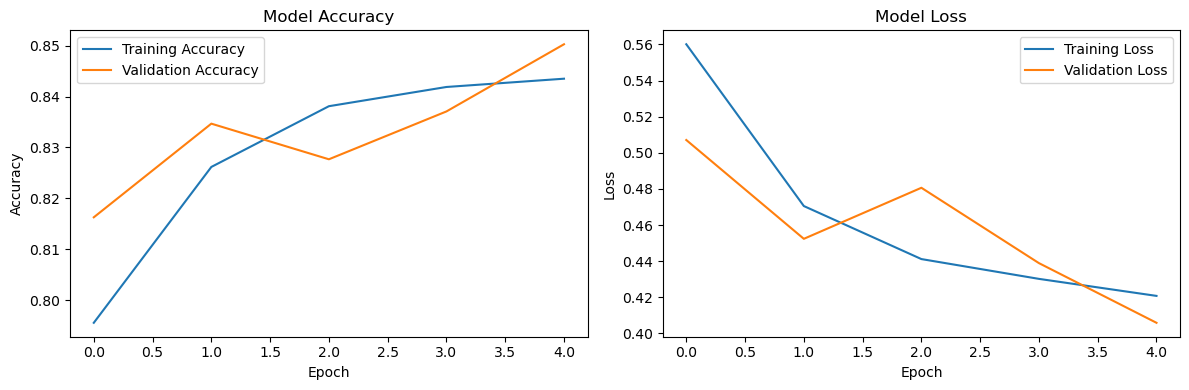

Final training accuracy: 0.8435
Final validation accuracy: 0.8503


In [160]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Trying to run in GPU if available
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU detected and enabled")
else:
    print("Running on CPU")

# Paths
train_dir = './yelp_photos/train_data'
test_dir = './yelp_photos/test_data'

# Image generators with preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Using Smaller image size for speed
TARGET_SIZE = (128, 128)  
BATCH_SIZE = 32

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Found {train_generator.samples} training images")
print(f"Found {test_generator.samples} validation images")
print(f"Number of classes: {len(train_generator.class_indices)}")

# Method 1: Simple image-only model fast model
def create_simple_model():
    model = tf.keras.Sequential([
        MobileNetV2(input_shape=(*TARGET_SIZE, 3), include_top=False, weights='imagenet'),
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(len(train_generator.class_indices), activation='softmax')
    ])
    
    # Freeze base model
    model.layers[0].trainable = False
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Method 2 Fast metadata + image model
class FastMetadataGenerator(Sequence):
    def __init__(self, image_generator, metadata_features):
        self.image_generator = image_generator
        self.metadata_features = metadata_features
        
    def __len__(self):
        return len(self.image_generator)
    
    def __getitem__(self, index):
        X_images, y_labels = self.image_generator[index]
        
        # Get metadata for this batch
        start_idx = index * self.image_generator.batch_size
        end_idx = start_idx + X_images.shape[0]
        X_metadata = self.metadata_features[start_idx:end_idx]
        
        # Ensure matching batch sizes
        if X_metadata.shape[0] != X_images.shape[0]:
            min_size = min(X_metadata.shape[0], X_images.shape[0])
            X_metadata = X_metadata[:min_size]
            X_images = X_images[:min_size]
            y_labels = y_labels[:min_size]
        
        return (X_images, X_metadata), y_labels

def create_metadata_model(metadata_dim):
    # Image input
    image_input = Input(shape=(*TARGET_SIZE, 3))
    base_model = MobileNetV2(input_shape=(*TARGET_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    
    x = base_model(image_input)
    x = GlobalAveragePooling2D()(x)
    
    # Metadata input
    metadata_input = Input(shape=(metadata_dim,))
    
    # Combine
    combined = Concatenate()([x, metadata_input])
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(len(train_generator.class_indices), activation='softmax')(x)
    
    model = Model(inputs=[image_input, metadata_input], outputs=x)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# STARTING WITH SIMPLE MODEL FIRST
print("Creating simple image-only model...")
model = create_simple_model()
model.summary()

# Train the simple model
print("Starting training (image-only)...")
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    verbose=1
)

print("Training completed!")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

## Model Parameters, Confusion Matrix and Evaluation Metrics

In [176]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import tensorflow as tf

MODEL ARCHITECTURE SUMMARY
Total Parameters: 2,422,597
Trainable Parameters: 164,613
Non-trainable Parameters: 2,257,984
Model Memory Usage: ~9.24 MB

LAYER-WISE PARAMETER COUNT
 1. mobilenetv2_1.00_128      |  2,257,984 params | Trainable: ✗
 2. global_average_pooling2d_1 |          0 params | Trainable: ✓
 3. dropout_20                |          0 params | Trainable: ✓
 4. dense_30                  |    163,968 params | Trainable: ✓
 5. dropout_21                |          0 params | Trainable: ✓
 6. dense_31                  |        645 params | Trainable: ✓

Total Layer Parameters: 2,422,597

MODEL INPUT/OUTPUT SHAPES
Input shape: (None, 128, 128, 3)
Output shape: (None, 5)

DETAILED LAYER INFORMATION
mobilenetv2_1.00_128: Functional
global_average_pooling2d_1: GlobalAveragePooling2D
dropout_20: dropout rate 0.2
dense_30: 128 units, activation: relu
dropout_21: dropout rate 0.2
dense_31: 5 units, activation: softmax
GENERATING PREDICTIONS...
313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 376ms

<Figure size 1200x1000 with 0 Axes>

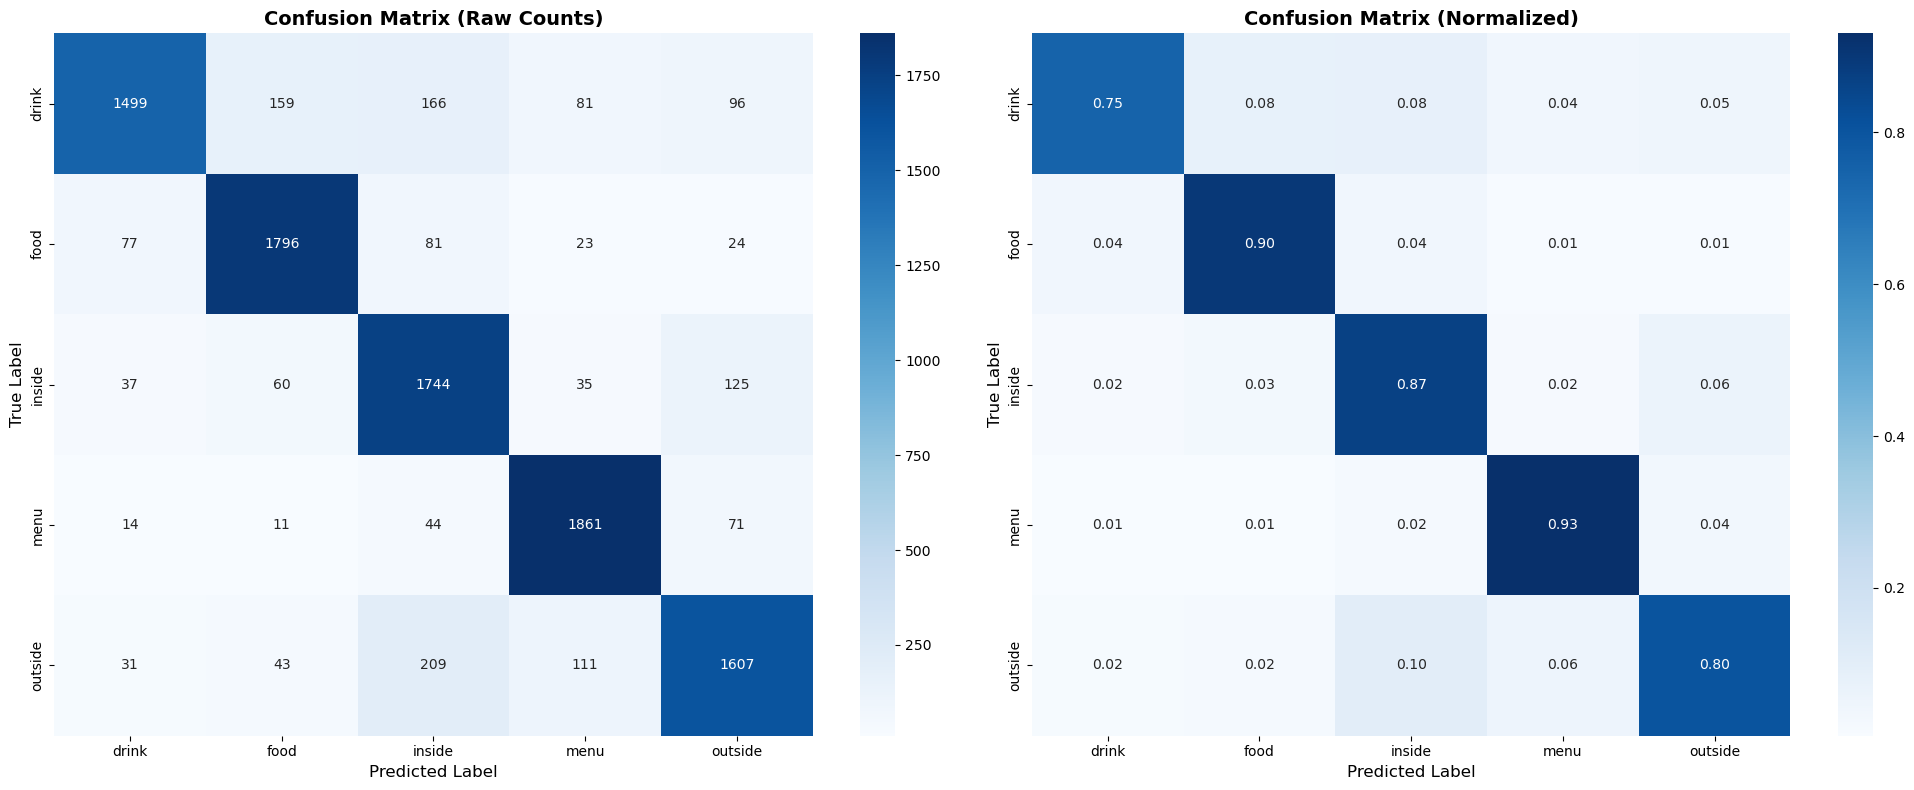


CLASSIFICATION METRICS
Overall Accuracy: 0.8503 (85.03%)

Macro Average - Precision: 0.8533, Recall: 0.8503, F1: 0.8496
Weighted Average - Precision: 0.8533, Recall: 0.8503, F1: 0.8496

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       drink     0.9041    0.7491    0.8193      2001
        food     0.8681    0.8976    0.8826      2001
      inside     0.7772    0.8716    0.8217      2001
        menu     0.8816    0.9300    0.9052      2001
     outside     0.8357    0.8031    0.8191      2001

    accuracy                         0.8503     10005
   macro avg     0.8533    0.8503    0.8496     10005
weighted avg     0.8533    0.8503    0.8496     10005


PER-CLASS PERFORMANCE
Class           Precision  Recall     F1-Score   Support   
------------------------------------------------------------
drink           0.9041     0.7491     0.8193     2001      
food            0.8681     0.8976     0.8826     2001      
inside          0.7772     0.

<Figure size 1500x500 with 0 Axes>

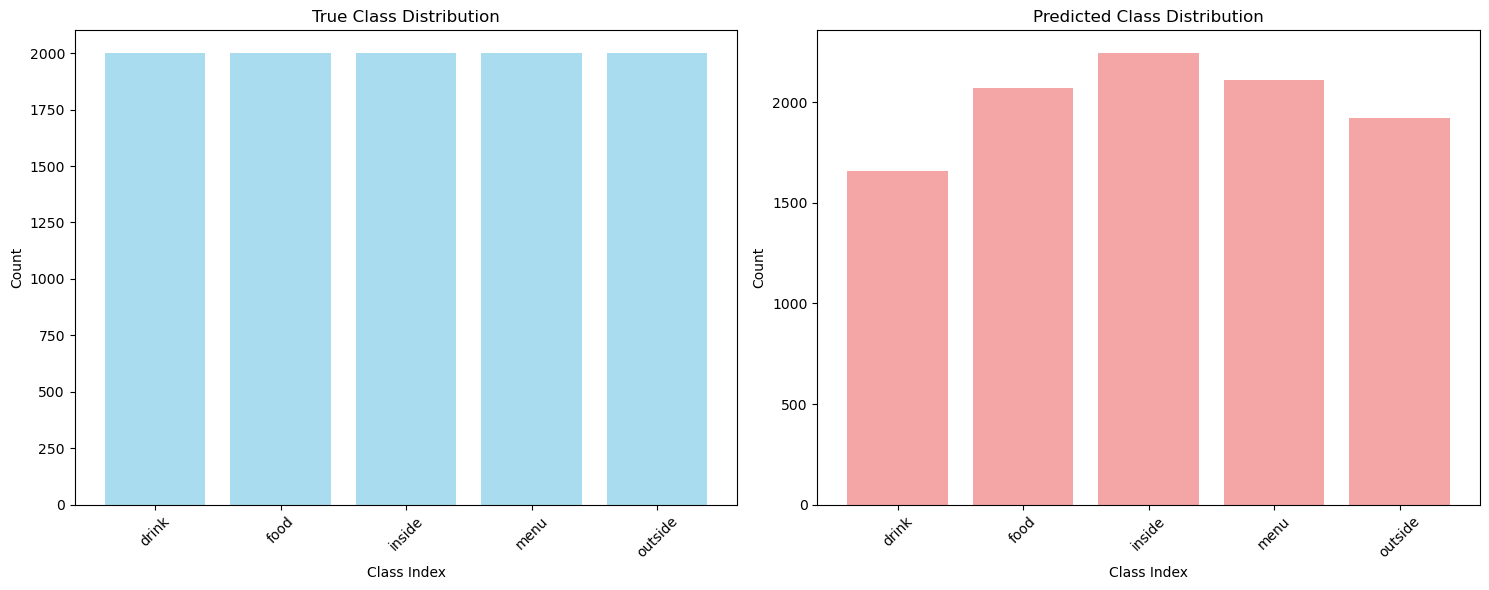


ADDITIONAL MODEL INSIGHTS
Model Complexity: Medium
Estimated Inference Time: Fast
Best performing class: menu (F1: 0.9052)
Worst performing class: outside (F1: 0.8191)


In [178]:
# MODEL PARAMETERS ANALYSIS

def print_model_parameters(model):
    """Print detailed model parameters and architecture info"""
    
    print("=" * 60)
    print("MODEL ARCHITECTURE SUMMARY")
    print("=" * 60)
    
    # Basic model info
    total_params = model.count_params()
    trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-trainable Parameters: {non_trainable_params:,}")
    print(f"Model Memory Usage: ~{total_params * 4 / (1024**2):.2f} MB")
    
    print("\n" + "=" * 60)
    print("LAYER-WISE PARAMETER COUNT")
    print("=" * 60)
    
    total_layer_params = 0
    for i, layer in enumerate(model.layers):
        layer_params = layer.count_params()
        total_layer_params += layer_params
        trainable = "✓" if layer.trainable else "✗"
        print(f"{i+1:2d}. {layer.name:25s} | {layer_params:>10,} params | Trainable: {trainable}")
    
    print(f"\nTotal Layer Parameters: {total_layer_params:,}")
    
    # Model input/output shapes
    print("\n" + "=" * 60)
    print("MODEL INPUT/OUTPUT SHAPES")
    print("=" * 60)
    
    if hasattr(model, 'input_shape'):
        if isinstance(model.input_shape, list):
            for i, shape in enumerate(model.input_shape):
                print(f"Input {i+1} shape: {shape}")
        else:
            print(f"Input shape: {model.input_shape}")
    
    if hasattr(model, 'output_shape'):
        print(f"Output shape: {model.output_shape}")
    
    # Detailed layer information
    print("\n" + "=" * 60)
    print("DETAILED LAYER INFORMATION")
    print("=" * 60)
    
    for layer in model.layers:
        if hasattr(layer, 'filters') and layer.filters:
            print(f"{layer.name}: {layer.filters} filters, kernel size {layer.kernel_size}")
        elif hasattr(layer, 'units') and layer.units:
            print(f"{layer.name}: {layer.units} units, activation: {layer.activation.__name__}")
        elif 'dropout' in layer.name.lower():
            print(f"{layer.name}: dropout rate {layer.rate}")
        else:
            print(f"{layer.name}: {type(layer).__name__}")


# CONFUSION MATRIX AND EVALUATION METRICS


def evaluate_model_comprehensive(model, test_generator, class_names=None):
    """Comprehensive model evaluation with confusion matrix and metrics"""
    
    print("=" * 60)
    print("GENERATING PREDICTIONS...")
    print("=" * 60)
    
    # Reset test generator
    test_generator.reset()
    
    # Get predictions
    predictions = model.predict(test_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get true labels
    true_classes = test_generator.classes
    
    # If generator doesn't have classes attribute, extract from batches
    if true_classes is None:
        print("Extracting true labels from generator...")
        true_classes = []
        test_generator.reset()
        
        for i in range(len(test_generator)):
            _, batch_labels = test_generator[i]
            true_classes.extend(np.argmax(batch_labels, axis=1))
        
        true_classes = np.array(true_classes)
    
    # Get class names
    if class_names is None:
        if hasattr(test_generator, 'class_indices'):
            class_names = list(test_generator.class_indices.keys())
        else:
            class_names = [f'Class_{i}' for i in range(len(np.unique(true_classes)))]
    
    print(f"Number of test samples: {len(true_classes)}")
    print(f"Number of classes: {len(class_names)}")
    
    # CONFUSION MATRIX

    print("\n" + "=" * 60)
    print("CONFUSION MATRIX")
    print("=" * 60)
    
    # Compute confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label', fontsize=12)
    ax1.set_ylabel('True Label', fontsize=12)
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('True Label', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # CLASSIFICATION METRICS
    
    print("\n" + "=" * 60)
    print("CLASSIFICATION METRICS")
    print("=" * 60)
    
    # Overall accuracy
    accuracy = accuracy_score(true_classes, predicted_classes)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        true_classes, predicted_classes, average=None, labels=range(len(class_names))
    )
    
    # Macro and weighted averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        true_classes, predicted_classes, average='macro'
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        true_classes, predicted_classes, average='weighted'
    )
    
    print(f"\nMacro Average - Precision: {precision_macro:.4f}, Recall: {recall_macro:.4f}, F1: {f1_macro:.4f}")
    print(f"Weighted Average - Precision: {precision_weighted:.4f}, Recall: {recall_weighted:.4f}, F1: {f1_weighted:.4f}")
    
    # Detailed classification report
    print("\n" + "=" * 60)
    print("DETAILED CLASSIFICATION REPORT")
    print("=" * 60)
    
    report = classification_report(true_classes, predicted_classes, 
                                 target_names=class_names, digits=4)
    print(report)
    
    # Per-class performance table
    print("\n" + "=" * 60)
    print("PER-CLASS PERFORMANCE")
    print("=" * 60)
    
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 60)
    
    for i, class_name in enumerate(class_names):
        print(f"{class_name:<15} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {support[i]:<10.0f}")
    
    # PREDICTION DISTRIBUTION
   
    print("\n" + "=" * 60)
    print("PREDICTION DISTRIBUTION")
    print("=" * 60)
    
    # Plot prediction distribution
    plt.figure(figsize=(15, 5))
    
    # True vs Predicted distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    unique_true, counts_true = np.unique(true_classes, return_counts=True)
    unique_pred, counts_pred = np.unique(predicted_classes, return_counts=True)
    
    ax1.bar(range(len(unique_true)), counts_true, alpha=0.7, color='skyblue', label='True')
    ax1.set_xlabel('Class Index')
    ax1.set_ylabel('Count')
    ax1.set_title('True Class Distribution')
    ax1.set_xticks(range(len(class_names)))
    ax1.set_xticklabels(class_names, rotation=45)
    
    ax2.bar(range(len(unique_pred)), counts_pred, alpha=0.7, color='lightcoral', label='Predicted')
    ax2.set_xlabel('Class Index')
    ax2.set_ylabel('Count')
    ax2.set_title('Predicted Class Distribution')
    ax2.set_xticks(range(len(class_names)))
    ax2.set_xticklabels(class_names, rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Return metrics for further analysis
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'confusion_matrix': cm,
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'true_classes': true_classes
    }


# Getting best model parameters

# Print model parameters
print_model_parameters(model)

# Comprehensive evaluation
metrics = evaluate_model_comprehensive(model, test_generator)

# Additional analysis
print("\n" + "=" * 60)
print("ADDITIONAL MODEL INSIGHTS")
print("=" * 60)

# Model complexity analysis
total_params = model.count_params()
if total_params < 1e6:
    complexity = "Light"
elif total_params < 1e7:
    complexity = "Medium"
else:
    complexity = "Heavy"

print(f"Model Complexity: {complexity}")
print(f"Estimated Inference Time: {'Fast' if total_params < 5e6 else 'Medium' if total_params < 2e7 else 'Slow'}")

# Best and worst performing classes
f1_scores = metrics['f1']
best_class_idx = np.argmax(f1_scores)
worst_class_idx = np.argmin(f1_scores)

class_names = list(test_generator.class_indices.keys()) if hasattr(test_generator, 'class_indices') else [f'Class_{i}' for i in range(len(f1_scores))]

print(f"Best performing class: {class_names[best_class_idx]} (F1: {f1_scores[best_class_idx]:.4f})")
print(f"Worst performing class: {class_names[worst_class_idx]} (F1: {f1_scores[worst_class_idx]:.4f})")

### LLM Prompts
- how do i implement guassian blur, threshold and histogram equalization
- naming issue while splitting train and test data
- how to speed up vgg16 model
- give code to print the model parameters